# Predictor Retrieval and Merging

In this analysis, we will retrieve and merge predictors for DEM1 as follows:

- ATR and MACD predictors for 1h candles
- Swing High/Low predictors for 15min candles

All predictors will be merged into a single DataFrame, aligned by timestamp where possible.

In [1]:
# Import required libraries
import pandas as pd
from Database.DB_reader import Database
from Database.Timescale import utils

In [2]:
# Connect to the database
conn = Database('timescaledb')

# Define predictor names for DEM1
atr_pred_name = 'atr_dem1_candles_1h_lookback_21'
macd_pred_name = 'macd_macd_dem1_candles_1h_params_12_26_9'
macd_hist_pred_name = 'macd_hist_dem1_candles_1h_params_12_26_9'
swing_high_pred_name = 'swing_high_dem1_candles_15min'
swing_low_pred_name = 'swing_low_dem1_candles_15min'

# Query for ATR (1h)
atr_query = f"""
SELECT datetime, nanotime, tradeid, pred_value as atr
FROM public.experimental_dataset_entries
WHERE pred_id = 202 AND pred_value IS NOT NULL
ORDER BY datetime, nanotime, tradeid
"""
atr_1h = conn.execute_general_query(atr_query)

# Fill ATR 0 values with last non-zero value
atr_1h['atr'] = atr_1h['atr'].astype(float)
atr_1h = atr_1h.dropna(subset=['atr'])  # Drop rows where ATR is NaN before forward fill
atr_1h['atr'] = atr_1h['atr'].replace(0, pd.NA)
atr_1h = atr_1h.dropna(subset=['atr'])  # Drop rows where ATR is NaN before forward fill
atr_1h['atr'] = atr_1h['atr'].fillna(method='ffill')
atr_1h['atr'] = atr_1h['atr'].fillna(0)  # In case the first value(s) are zero

# Query for MACD (1h)
macd_query = f"""
SELECT datetime, nanotime, tradeid, pred_value as macd
FROM public.experimental_dataset_entries
WHERE pred_id = 217 AND pred_value IS NOT NULL
ORDER BY datetime, nanotime, tradeid
"""
macd_1h = conn.execute_general_query(macd_query)

# Query for MACD histogram (1h)
macd_hist_query = f"""
SELECT datetime, nanotime, tradeid, pred_value as macd_hist
FROM public.experimental_dataset_entries
WHERE pred_id = 219 AND pred_value IS NOT NULL
ORDER BY datetime, nanotime, tradeid
"""
macd_hist_1h = conn.execute_general_query(macd_hist_query)

# Merge MACD and MACD histogram
macd_full_1h = pd.merge(macd_1h, macd_hist_1h, on=['datetime', 'nanotime', 'tradeid'], how='outer')

# Merge ATR and MACD
predictors_1h = pd.merge(atr_1h, macd_full_1h, on=['datetime', 'nanotime', 'tradeid'], how='outer')

Connected to the database timescaledb
Disconnected from the database timescaledb
Disconnected from the database timescaledb


C:\Users\krajcovic\AppData\Local\Temp\ipykernel_59024\3080166229.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  atr_1h['atr'] = atr_1h['atr'].fillna(method='ffill')
C:\Users\krajcovic\AppData\Local\Temp\ipykernel_59024\3080166229.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  atr_1h['atr'] = atr_1h['atr'].fillna(method='ffill')


Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Disconnected from the database timescaledb


In [3]:
# Query for swing high (15min)
swing_high_query = f"""
SELECT datetime, nanotime, tradeid, pred_value as swing_high
FROM public.experimental_dataset_entries
WHERE pred_id = 304 AND pred_value IS NOT NULL
ORDER BY datetime, nanotime, tradeid
"""
swing_high_15m = conn.execute_general_query(swing_high_query)

# Query for swing low (15min)
swing_low_query = f"""
SELECT datetime, nanotime, tradeid, pred_value as swing_low
FROM public.experimental_dataset_entries
WHERE pred_id = 305 AND pred_value IS NOT NULL
ORDER BY datetime, nanotime, tradeid
"""
swing_low_15m = conn.execute_general_query(swing_low_query)

# Convert swing high/low columns to numeric after querying from database
swing_high_15m['swing_high'] = pd.to_numeric(swing_high_15m['swing_high'], errors='coerce')
swing_low_15m['swing_low'] = pd.to_numeric(swing_low_15m['swing_low'], errors='coerce')

# Merge swing high and low
swing_15m = pd.merge(swing_high_15m, swing_low_15m, on=['datetime', 'nanotime', 'tradeid'], how='outer')

Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Disconnected from the database timescaledb


In [4]:
# Merge all predictors into a single DataFrame
# Merge on ['datetime', 'nanotime', 'tradeid']
merged = predictors_1h.merge(swing_15m, on=['datetime', 'nanotime', 'tradeid'], how='outer').dropna()

# Display the merged DataFrame
merged.head()

,datetime,nanotime,tradeid,atr,macd,macd_hist,swing_high,swing_low
61747,2025-01-07 11:00:00,10954219.0,Eurex T7/F7BQ072025-20250107/3467/1,0.839091,-2.040487577124267,-0.4181261842496291,105.87,104.35
61748,2025-01-07 11:00:00,10954219.0,Eurex T7/FDBQ072025-20250107/3467/1,0.839091,-2.040487577124267,-0.4181261842496291,105.87,104.35
61749,2025-01-07 11:00:00,301763248.0,Eurex T7/G3BM022025-20250107/3468/3,0.839091,-2.040487577124267,-0.4181261842496291,105.87,104.35
61750,2025-01-07 11:00:01,449676030.0,Eurex T7/G3BQ012026-20250107/3469/1,0.839091,-2.040487577124267,-0.4181261842496291,105.87,104.35
61751,2025-01-07 11:00:01,769000000.0,5338890,0.839091,-2.040487577124267,-0.4181261842496291,105.87,104.35


In [5]:
# Normalize MACD and MACD histogram by ATR
merged['atr'] = merged['atr'].astype(float)
merged['macd'] = merged['macd'].astype(float)
merged['macd_hist'] = merged['macd_hist'].astype(float)

merged['macd_norm'] = merged['macd'] / merged['atr']
merged['macd_hist_norm'] = merged['macd_hist'] / merged['atr']

# Display the normalized columns
merged[['datetime', 'nanotime', 'tradeid', 'macd_norm', 'macd_hist_norm']].dropna().head()

,datetime,nanotime,tradeid,macd_norm,macd_hist_norm
61747,2025-01-07 11:00:00,10954219.0,Eurex T7/F7BQ072025-20250107/3467/1,-2.431784,-0.498309
61748,2025-01-07 11:00:00,10954219.0,Eurex T7/FDBQ072025-20250107/3467/1,-2.431784,-0.498309
61749,2025-01-07 11:00:00,301763248.0,Eurex T7/G3BM022025-20250107/3468/3,-2.431784,-0.498309
61750,2025-01-07 11:00:01,449676030.0,Eurex T7/G3BQ012026-20250107/3469/1,-2.431784,-0.498309
61751,2025-01-07 11:00:01,769000000.0,5338890,-2.431784,-0.498309


In [6]:
# Show distributions of all columns except for common keys
dist_cols = [col for col in merged.columns if col not in ['datetime', 'nanotime', 'tradeid']]
distributions = merged[dist_cols].describe().T
print(distributions)
distributions

                    count       mean        std        min        25%  \
atr             1168748.0   0.930825   0.257521   0.323636   0.725909   
macd            1168748.0  -0.045800   1.077834  -2.881526  -0.812735   
macd_hist       1168748.0   0.025590   0.332795  -0.729012  -0.215864   
swing_high      1168748.0  86.232852  15.495144  62.920000  74.510000   
swing_low       1168748.0  83.572905  14.997499  60.070000  72.550000   
macd_norm       1168748.0  -0.019218   1.094320  -2.570059  -0.850079   
macd_hist_norm  1168748.0   0.024291   0.352893  -0.692598  -0.247590   

                      50%        75%         max  
atr              0.909091   1.131364    1.647727  
macd             0.100821   0.732377    3.981992  
macd_hist       -0.003717   0.243775    1.387667  
swing_high      81.100000  98.730000  125.840000  
swing_low       78.470000  95.640000  123.220000  
macd_norm        0.108322   0.812203    2.854475  
macd_hist_norm  -0.004298   0.256312    1.085253  


,count,mean,std,min,25%,50%,75%,max
atr,1168748.0,0.930825,0.257521,0.323636,0.725909,0.909091,1.131364,1.647727
macd,1168748.0,-0.045800,1.077834,-2.881526,-0.812735,0.100821,0.732377,3.981992
macd_hist,1168748.0,0.025590,0.332795,-0.729012,-0.215864,-0.003717,0.243775,1.387667
swing_high,1168748.0,86.232852,15.495144,62.920000,74.510000,81.100000,98.730000,125.840000
swing_low,1168748.0,83.572905,14.997499,60.070000,72.550000,78.470000,95.640000,123.220000
macd_norm,1168748.0,-0.019218,1.094320,-2.570059,-0.850079,0.108322,0.812203,2.854475
macd_hist_norm,1168748.0,0.024291,0.352893,-0.692598,-0.247590,-0.004298,0.256312,1.085253


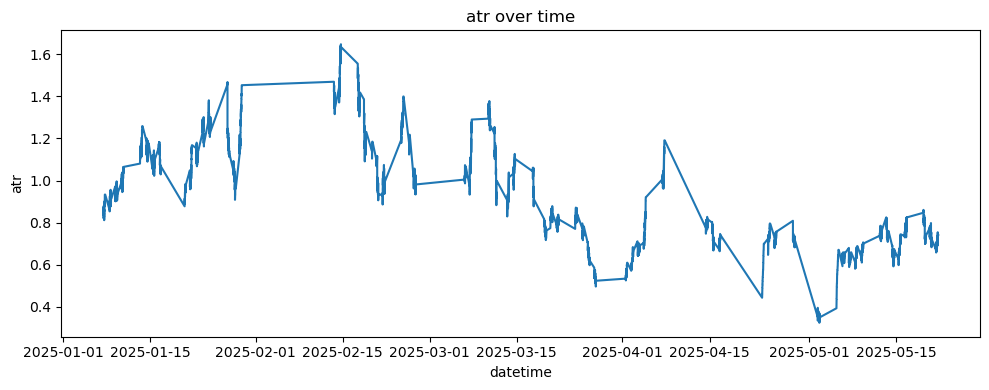

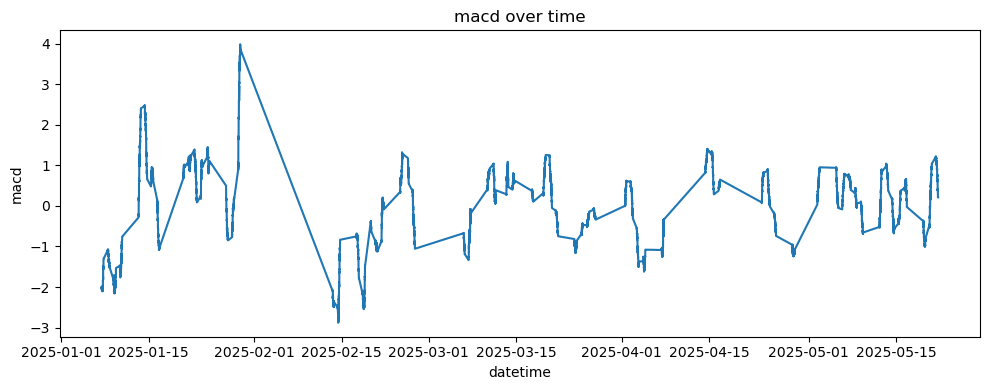

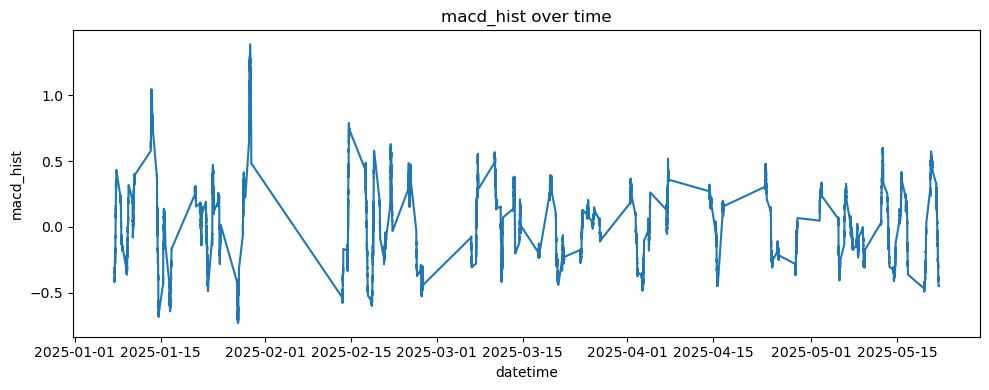

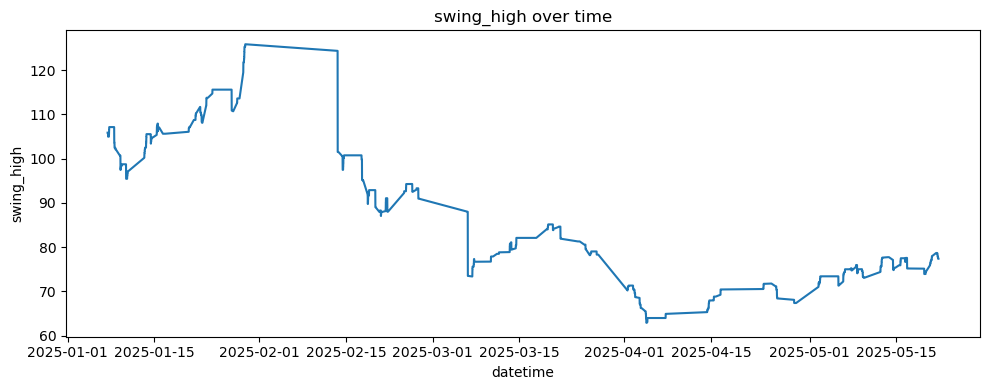

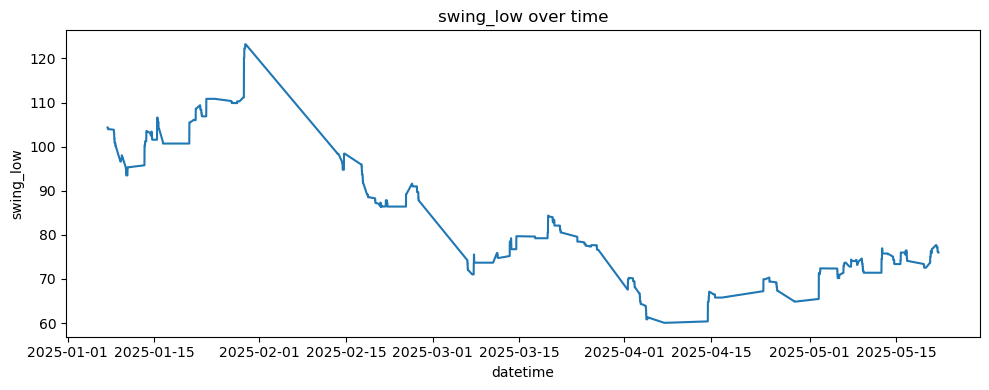

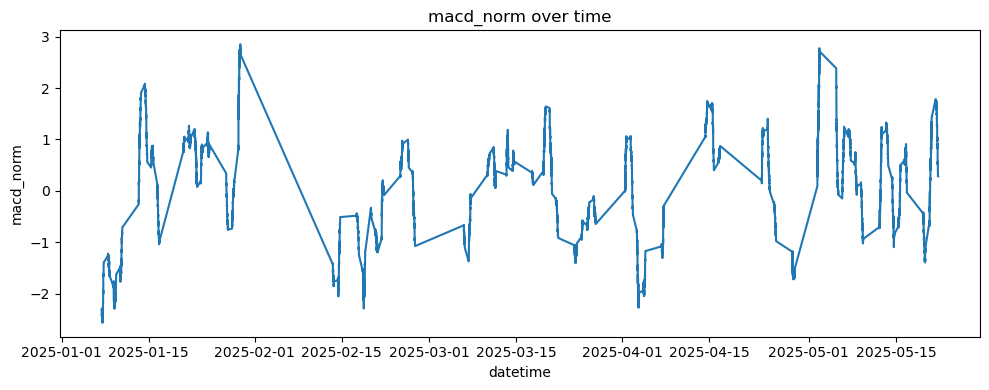

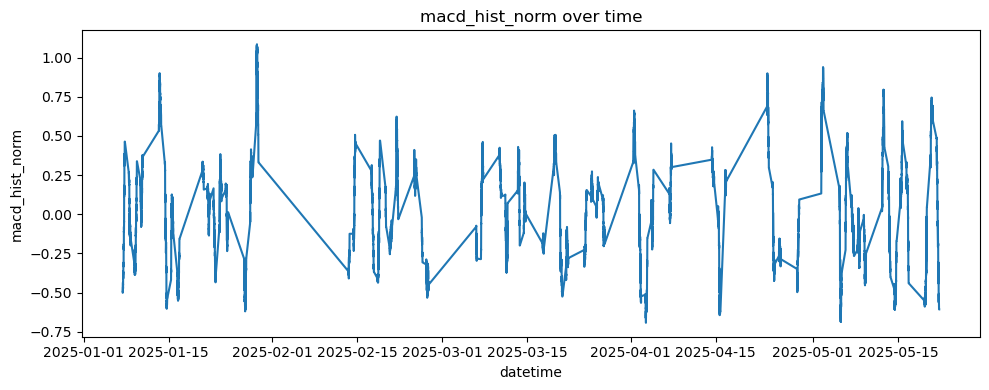

In [7]:
# Plot each predictor and normalized column (except for keys)
import matplotlib.pyplot as plt

dist_cols = [col for col in merged.columns if col not in ['datetime', 'nanotime', 'tradeid']]
for col in dist_cols:
    plt.figure(figsize=(10, 4))
    plt.plot(merged['datetime'], merged[col])
    plt.title(f'{col} over time')
    plt.xlabel('datetime')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
# Query timestamps as in atr_inject.py
conn = Database('timescaledb')
START_DATE = '2025-01-01'
END_DATE = '2025-05-29'
timestamps = conn.execute_general_query(
    f"""
    SELECT DISTINCT datetime, nanotime, tradeid FROM public.trades
    WHERE datetime >= '{START_DATE}' AND datetime <= '{END_DATE}'
    AND EXTRACT(HOUR FROM datetime) BETWEEN 8 AND 18
    AND instid IN ('10641710', '10001075', '10100480', '10012528', '10002806')
    ORDER BY datetime ASC, nanotime ASC
    """
)



# Fetch DEM1 trades using utils.get_trades_data (as in atr_inject.py)
trades = utils.get_trades_data('dem1', START_DATE, END_DATE)
trades = trades.reset_index()  # Ensure datetime is a column, not index

# Merge timestamps with DEM1 trades on tradeid (and all keys)
trades_merged = timestamps.merge(
    trades[['tradeid','price']],
    on=['tradeid'],
    how='left'
)
trades_merged.set_index('datetime', inplace=True)
trades_merged = trades_merged.ffill()

# Display merged trades
display(trades_merged.head())

Connected to the database timescaledb


In [ ]:
trades_merged.head()

,nanotime,tradeid,price
datetime,,,
2025-01-01 08:17:40,70000000.0,16663069,NaN
2025-01-01 08:19:38,392000000.0,16663072,NaN
2025-01-01 09:27:49,150000000.0,16663099,NaN
2025-01-01 09:28:08,136000000.0,16663100,NaN
2025-01-01 09:28:09,105000000.0,16663101,NaN


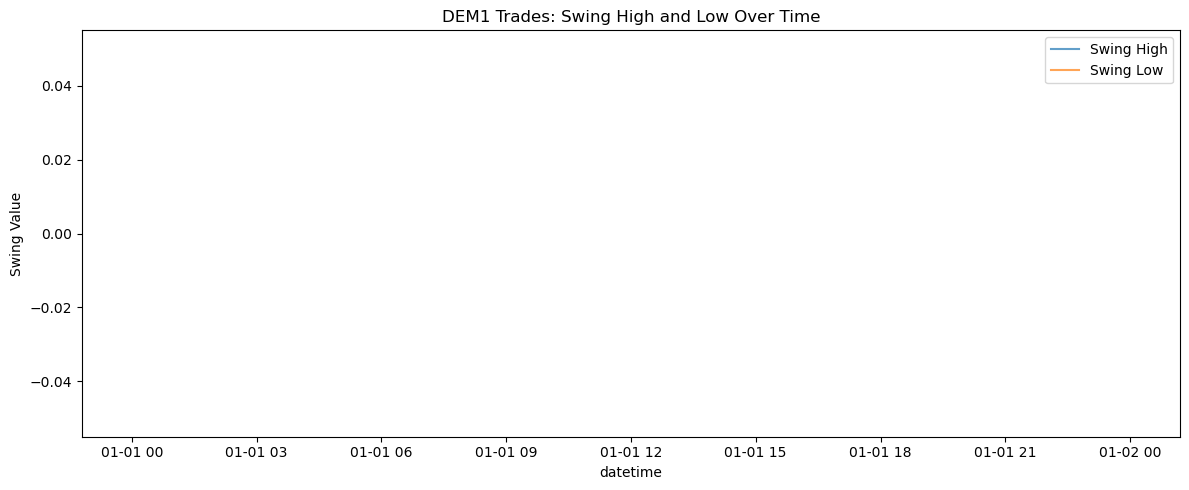

In [ ]:
# Merge trades with swing high/low data on ['datetime', 'nanotime', 'tradeid']
trades_merged_s = trades_merged.merge(swing_15m, on=['datetime', 'tradeid'], how='left').ffill()

# Plot swing high and swing low over time for DEM1 trades
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(trades_merged_s['datetime'], trades_merged_s['swing_high'], label='Swing High', alpha=0.7)
plt.plot(trades_merged_s['datetime'], trades_merged_s['swing_low'], label='Swing Low', alpha=0.7)
plt.xlabel('datetime')
plt.ylabel('Swing Value')
plt.title('DEM1 Trades: Swing High and Low Over Time')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
trades_merged_s

,datetime,nanotime_x,tradeid,price,nanotime_y,swing_high,swing_low
0,2025-01-01 08:17:40,70000000.0,16663069,NaN,NaN,NaN,NaN
1,2025-01-01 08:19:38,392000000.0,16663072,NaN,NaN,NaN,NaN
2,2025-01-01 09:27:49,150000000.0,16663099,NaN,NaN,NaN,NaN
3,2025-01-01 09:28:08,136000000.0,16663100,NaN,NaN,NaN,NaN
4,2025-01-01 09:28:09,105000000.0,16663101,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2072104,2025-05-28 18:52:30,718000000.0,18064503,72.3,NaN,NaN,NaN
2072105,2025-05-28 18:55:31,329000000.0,18064509,72.3,NaN,NaN,NaN
2072106,2025-05-28 18:55:32,657000000.0,18064510,72.3,NaN,NaN,NaN
2072107,2025-05-28 18:56:56,477000000.0,18064511,72.3,NaN,NaN,NaN


In [ ]:
# Inspect missing values in swing high/low data
print('Swing High missing:', swing_15m['swing_high'].isna().sum(), 'of', len(swing_15m))
print('Swing Low missing:', swing_15m['swing_low'].isna().sum(), 'of', len(swing_15m))
print('Rows with both missing:', swing_15m[swing_15m['swing_high'].isna() & swing_15m['swing_low'].isna()].shape[0])

# Show a sample of rows with missing swing high/low
display(swing_15m[swing_15m['swing_high'].isna() | swing_15m['swing_low'].isna()].head(10))

Swing High missing: 0 of 0
Swing Low missing: 0 of 0
Rows with both missing: 0


,datetime,nanotime,tradeid,swing_high,swing_low


In [ ]:
# Merge swing high/low data with timestamps (left merge to align with all timestamps)
swing_15m_aligned = timestamps.merge(swing_15m, on=['tradeid'], how='left')

# Count missing values after alignment
print('Swing High missing after alignment:', swing_15m_aligned['swing_high'].isna().sum(), 'of', len(swing_15m_aligned))
print('Swing Low missing after alignment:', swing_15m_aligned['swing_low'].isna().sum(), 'of', len(swing_15m_aligned))
print('Rows with both missing after alignment:', swing_15m_aligned[swing_15m_aligned['swing_high'].isna() & swing_15m_aligned['swing_low'].isna()].shape[0])

# Show a sample of rows with missing swing high/low after alignment
display(swing_15m_aligned[swing_15m_aligned['swing_high'].isna() | swing_15m_aligned['swing_low'].isna()].head(10))

Swing High missing after alignment: 2072109 of 2072109
Swing Low missing after alignment: 2072109 of 2072109
Rows with both missing after alignment: 2072109


,datetime_x,nanotime_x,tradeid,datetime_y,nanotime_y,swing_high,swing_low
0,2025-01-01 08:17:40,70000000.0,16663069,NaN,NaN,NaN,NaN
1,2025-01-01 08:19:38,392000000.0,16663072,NaN,NaN,NaN,NaN
2,2025-01-01 09:27:49,150000000.0,16663099,NaN,NaN,NaN,NaN
3,2025-01-01 09:28:08,136000000.0,16663100,NaN,NaN,NaN,NaN
4,2025-01-01 09:28:09,105000000.0,16663101,NaN,NaN,NaN,NaN
5,2025-01-01 09:28:12,74000000.0,16663102,NaN,NaN,NaN,NaN
6,2025-01-01 09:28:12,887000000.0,16663103,NaN,NaN,NaN,NaN
7,2025-01-01 09:43:57,433000000.0,16663107,NaN,NaN,NaN,NaN
8,2025-01-01 09:44:00,590000000.0,16663109,NaN,NaN,NaN,NaN
9,2025-01-01 09:48:50,661000000.0,16663114,NaN,NaN,NaN,NaN


In [ ]:
swing_15m.set_index('datetime')[['swing_high', 'swing_low']].resample('D').last().dropna().plot()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'